In [2]:
import pandas as pd
import numpy as np
import os
import re
from datetime import datetime, timedelta
from pathlib import Path
from APIcall_v2 import main_api_call

In [3]:
def create_emptydf(start_date,end_date):
    """
    Creates empty DataFrame with date range
    Args:
        start_date (str): Start date in 'yyyy-mm-dd' format
        end_date (str): End date in 'yyyy-mm-dd' format
        
    Returns:
        empty (df): Eempty df ready for population
    """
    # Convert start_date to a consistent format
    if isinstance(start_date, str):
        start_date = start_date.split(' ')[0]  # Remove time if present
        start = datetime.strptime(start_date, '%Y-%m-%d')
    elif isinstance(start_date, datetime):
        start = start_date.date()  # Extract date part if datetime object
    else:
        raise ValueError("Invalid start_date format")

    # Convert end_date to a consistent format
    if isinstance(end_date, str):
        end_date = end_date.split(' ')[0]  # Remove time if present
        end = datetime.strptime(end_date, '%Y-%m-%d')
    elif isinstance(end_date, datetime):
        end = end_date.date()  # Extract date part if datetime object
    else:
        raise ValueError("Invalid end_date format")


    date_range = pd.date_range(start, end)

    df = pd.DataFrame({'Date': date_range})
    
    df['Date'] = df['Date'].dt.strftime('%Y-%m-%d')
    df['nr. sessions'] = 0
    df['total km'] = 0.00
    df['km Z3-4'] = 0.00
    df['km Z5-T1-T2'] = 0.00
    df['hours alternative'] = 0.00
    return df

### these were in use before I made it work in memory

In [3]:
def readfiles(file_path="../data/external"):
    '''
    Creates lists of all csv files in directory

    Args: 
        file_path (str): the relative path for the folder that 
        contains all the activity files

    Returns:
        run_activities (list):
    '''
    fpath = Path(file_path)

    run_activities = list(fpath.glob(f'*Running_*.csv'))
    all_activities = list(fpath.glob(f'*.csv'))
    set_run = set(run_activities)
    set_all = set(all_activities)
    other_activities = list(set_all-set_run)

    return run_activities,other_activities

In [5]:
def readrun(file):
    df = pd.read_csv(file)
    return df

In [6]:
def populatebydate(emptydf,run_activities,other_activities,Z3_min, Z5_min):
    
    for i in emptydf['Date']:
        for file in run_activities:
            filedate =   datetime.strptime(str(file).split('_')[1], '%d-%m-%Y').strftime('%Y-%m-%d')
            if filedate == i:
                emptydf.loc[emptydf['Date'] == filedate,'nr. sessions'] += 1
                populateone(emptydf,str(file),Z3_min, Z5_min)


        for file in other_activities:
            filedate =  datetime.strptime(str(file).split('_')[1], '%d-%m-%Y').strftime('%Y-%m-%d')
            if filedate == i:
                temp_df= readrun(file)
                time_str = temp_df['Time'].iloc[-1]
                time_obj = datetime.strptime(time_str, '%H:%M:%S.%f').time()
                time_delta = timedelta(hours=time_obj.hour, minutes=time_obj.minute, seconds=time_obj.second, microseconds=time_obj.microsecond)
        
                hours_alternative = round(time_delta.total_seconds() / 3600, 2)

                emptydf.loc[emptydf['Date'] == filedate, 'hours alternative'] = hours_alternative

    df = emptydf
   
    return df

In [7]:
def populateone(df_prepop,filename, Z3_min, Z5_min):
    """
    Populates the empty DataFrame with the data from the file
    Args:
        df_prepop (df): DataFrame to be populated
        filename (str): Name of the file to be read
    Returns:
        df_postpop (df): Populated DataFrame
    """
    
    filedate =  datetime.strptime(filename.split('_')[1], '%d-%m-%Y').strftime('%Y-%m-%d')
    file_df = readrun(filename)
    
    file_df['Distance'] = pd.to_numeric(file_df['Distance'], errors='coerce')

    
    # df_prepop.loc[df_prepop['Date'] == filedate, 'total km'] = current_total_km + file_df['Distance'].iloc[-1]
    df_prepop.loc[df_prepop['Date'] == filedate,'total km'] += file_df['Distance'].iloc[-1]
    
    for idx, row in file_df.iloc[:-1].iterrows():
        hr = row['Avg HR']
        distance = row['Distance']
        if Z3_min <= hr < Z5_min:
            df_prepop.loc[df_prepop['Date'] == filedate, 'km Z3-4'] += distance
        elif hr >= Z5_min:
            df_prepop.loc[df_prepop['Date'] == filedate, 'km Z5-T1-T2'] += distance
    
    df_postpop = df_prepop
    return df_postpop 
   

### Need this, still in use

In [4]:
def convert_to_day_approach(df):
    """
    Converts the DataFrame to a day approach format.
    
    Args:
        df (DataFrame): The DataFrame to convert.
        
    Returns:
        DataFrame: The converted DataFrame into a format with 7 lagging days 
        before each date in the format 

    """
    feature_cols = ['nr. sessions', 'total km', 'km Z3-4', 'km Z5-T1-T2', 'hours alternative']
    df_converted = pd.DataFrame()
    for i in range(0,7):
        for col in feature_cols:
            df_converted[f'{col}.{i}'] = df[col].shift(i)  
    df_converted['Date'] = df['Date']
    # drop rows with NaN values using dropna() with index as the row
    df_converted = df_converted.dropna()

    # replace the name of the column with the name of the column without the last 2 characters
    df_converted = df_converted.rename(columns={col: col[:-2] for col in df_converted.columns if col.endswith('.0')})


    # return df_lagged
    return df_converted          


In [5]:
def read_df_memory(saved_activity_dictionary):
    '''
    separates out two lists of dictionaries from the downloaded_activities list

    Args: 
        df_memory (list): the list of dictionaries that contains all the downloaded activities in the format:
        {'filename': filename, 'data': data}

    Returns:
        run_activities (list), other_activities (list): two lists of dictionaries that contain the activities that are running and the rest of the activities
    '''
    run_activities = []
    other_activities = []
    for item in saved_activity_dictionary:
        filename = item["filename"]
        data = item["df"]
        # if filename  matches '*Running_*.csv':
        if re.match(r".*Running_.*\.csv$", filename):
            run_activities.append({'filename': filename, 'df': data})
        else:
            other_activities.append({'filename': filename, 'df': data})
    for item in run_activities:
        filename = item["filename"]
        print(filename)
    for item in other_activities:
        filename = item["filename"]
        print(filename)
    
    return run_activities, other_activities

### doesn't need to run for MVP2

In [16]:
'''#date_start = '2024-03-03'
 # date_end = '2024-09-15'
Z3_min = 135
Z5_min = 173
start_date, end_date, df_memory = main_api_call()

empty = create_emptydf(start_date, end_date)
r,o = read_df_memory(df_memory)
'''


"#date_start = '2024-03-03'\n # date_end = '2024-09-15'\nZ3_min = 135\nZ5_min = 173\nstart_date, end_date, df_memory = main_api_call()\n\nempty = create_emptydf(start_date, end_date)\nr,o = read_df_memory(df_memory)\n"

### do need this


In [6]:
def populateone_memory(df_prepop, file_df, filedate, Z3_min, Z5_min):
    """
    Populates the empty DataFrame with the data from the file
    Args:
        df_prepop (df): DataFrame to be populated
        file_df (df): DataFrame containing activity data
        filedate (str): Date of the activity
        Z3_min (int): Minimum heart rate for Z3 zone
        Z5_min (int): Minimum heart rate for Z5 zone
    Returns:
        df_postpop (df): Populated DataFrame
    """
    file_df['Distance'] = pd.to_numeric(file_df['Distance'], errors='coerce')

    df_prepop.loc[df_prepop['Date'] == filedate, 'total km'] += file_df['Distance'].iloc[-1]

    for idx, row in file_df.iloc[:-1].iterrows():
        hr = row['Avg HR']
        distance = row['Distance']
        if Z3_min <= hr < Z5_min:
            df_prepop.loc[df_prepop['Date'] == filedate, 'km Z3-4'] += distance
        elif hr >= Z5_min:
            df_prepop.loc[df_prepop['Date'] == filedate, 'km Z5-T1-T2'] += distance

    return df_prepop

In [7]:
def populatebydate_memory(emptydf, run_activities, other_activities, Z3_min, Z5_min):
    for i in emptydf['Date']:
        for activity in run_activities:
            filedate = datetime.strptime(activity['filename'].split('_')[1], '%d-%m-%Y').strftime('%Y-%m-%d')
            if filedate == i:
                emptydf.loc[emptydf['Date'] == filedate, 'nr. sessions'] += 1
                populateone_memory(emptydf, activity['df'], filedate, Z3_min, Z5_min)

        for activity in other_activities:
            filedate = datetime.strptime(activity['filename'].split('_')[1], '%d-%m-%Y').strftime('%Y-%m-%d')
            if filedate == i:
                temp_df = activity['df']
                time_str = temp_df['Time'].iloc[-1]
                time_obj = datetime.strptime(time_str, '%H:%M:%S.%f').time()
                time_delta = timedelta(hours=time_obj.hour, minutes=time_obj.minute, seconds=time_obj.second, microseconds=time_obj.microsecond)

                hours_alternative = round(time_delta.total_seconds() / 3600, 2)
                emptydf.loc[emptydf['Date'] == filedate, 'hours alternative'] = hours_alternative

    return emptydf

### this runs already inside main

In [ ]:
'''df_full = populatebydate_memory(empty, r, o, Z3_min, Z5_min)
# Convert to day approach
df_converted = convert_to_day_approach(df_full)
df_converted'''

NameError: name 'empty' is not defined

# Deprecated function

In [22]:
'''
def main_extract_transform(date_start, date_end, Z3_min = 135, Z5_min = 173):   
    """
    Main function to extract and transform data.
    """
    while True:
        # the z3_min and Z5 min need to be inputted by the user here
        Z3_min = input("Enter the minimum heart rate for your Z3 according to garmin: ") 
        Z5_min = input("Enter the minimim heart rate for your Z5 according to garmin: ")
        # wrap the input in a try except block to check if the input is a number
        try:
            Z3_min = int(Z3_min)
            Z5_min = int(Z5_min)
            break
        except ValueError:
            print("Please enter valid numbers for heart rate zone thresholds.")


    # Create an empty DataFrame for the specified date range
    empty = create_emptydf(date_start, date_end)
    
    # Read files and populate the DataFrame
    r, o = readfiles()
    df_full = populatebydate(empty, r, o, Z3_min, Z5_min)
    
    # Convert to day approach format
    dfday_user = convert_to_day_approach(df_full)

    df_full = populatebydate_memory(empty, r, o, Z3_min, Z5_min)
    # Convert to day approach
    df_converted = convert_to_day_approach(df_full)
    df_converted
    
    return dfday_user

'''

'\ndef main_extract_transform(date_start, date_end, Z3_min = 135, Z5_min = 173):   \n    """\n    Main function to extract and transform data.\n    """\n    while True:\n        # the z3_min and Z5 min need to be inputted by the user here\n        Z3_min = input("Enter the minimum heart rate for your Z3 according to garmin: ") \n        Z5_min = input("Enter the minimim heart rate for your Z5 according to garmin: ")\n        # wrap the input in a try except block to check if the input is a number\n        try:\n            Z3_min = int(Z3_min)\n            Z5_min = int(Z5_min)\n            break\n        except ValueError:\n            print("Please enter valid numbers for heart rate zone thresholds.")\n\n\n    # Create an empty DataFrame for the specified date range\n    empty = create_emptydf(date_start, date_end)\n    \n    # Read files and populate the DataFrame\n    r, o = readfiles()\n    df_full = populatebydate(empty, r, o, Z3_min, Z5_min)\n    \n    # Convert to day approach f

In [23]:
# main_extract_transform(date_start, date_end, Z3_min, Z5_min)

# in use Function


In [11]:
def main_extract_transform_memory(date_start, date_end, df_memory, Z3_min = 135, Z5_min = 173):   
    """
    Main function to extract and transform data.
    """
    while True:
        # the z3_min and Z5 min need to be inputted by the user here
        Z3_min = input("Enter the minimum heart rate for your Z3 according to garmin: ") 
        Z5_min = input("Enter the minimim heart rate for your Z5 according to garmin: ")
        # wrap the input in a try except block to check if the input is a number
        try:
            Z3_min = int(Z3_min)
            Z5_min = int(Z5_min)
            break
        except ValueError:
            print("Please enter valid numbers for heart rate zone thresholds.")

   

    empty = create_emptydf(start_date, end_date)
    r,o = read_df_memory(df_memory)
    
    df_full = populatebydate_memory(empty, r, o, Z3_min, Z5_min)
    
    # Convert to day approach format
    dfday_user = convert_to_day_approach(df_full)
    
    return dfday_user

## Implementation and exploration for MVP2

In [9]:
start_date, end_date, df_memory = main_api_call()

Garmin Connect API - Activity Downloader
Login successful!
Activity data for 'County Cork Running_14-09-2024_17035649561.csv' loaded into DataFrame.
Activity data for 'County Cork Running_08-09-2024_16978302936.csv' loaded into DataFrame.
Activity data for 'Cardio_07-09-2024_16974229631.csv' loaded into DataFrame.
Activity data for 'Cardio_04-09-2024_16947655452.csv' loaded into DataFrame.
Activity data for 'County Cork Running_04-09-2024_16943252511.csv' loaded into DataFrame.
Activity data for 'County Cork Running_03-09-2024_16938907167.csv' loaded into DataFrame.
Activity data for 'County Cork Running_01-09-2024_16922367627.csv' loaded into DataFrame.
Activity data for 'County Cork Running_01-09-2024_16919418278.csv' loaded into DataFrame.
Activity data for 'County Cork Running_01-09-2024_16919416736.csv' loaded into DataFrame.
Activity data for 'County Cork Running_01-09-2024_16919415814.csv' loaded into DataFrame.
Activity data for 'County Cork Running_30-08-2024_16902606657.csv' 

In [79]:
df = main_extract_transform_memory(start_date, end_date, df_memory)
df

County Cork Running_14-09-2024_17035649561.csv
County Cork Running_08-09-2024_16978302936.csv
County Cork Running_04-09-2024_16943252511.csv
County Cork Running_03-09-2024_16938907167.csv
County Cork Running_01-09-2024_16922367627.csv
County Cork Running_01-09-2024_16919418278.csv
County Cork Running_01-09-2024_16919416736.csv
County Cork Running_01-09-2024_16919415814.csv
County Cork Running_30-08-2024_16902606657.csv
County Cork Running_29-08-2024_16895365540.csv
County Cork Running_27-08-2024_16877314166.csv
County Cork Running_26-08-2024_16869210015.csv
County Cork Running_25-08-2024_16857259342.csv
County Cork Running_23-08-2024_16842019806.csv
County Cork Running_22-08-2024_16833431985.csv
County Cork Running_20-08-2024_16815720105.csv
County Cork Running_17-08-2024_16786745683.csv
County Cork Running_16-08-2024_16780867984.csv
County Cork Running_15-08-2024_16772244662.csv
County Cork Running_12-08-2024_16746046374.csv
County Cork Running_11-08-2024_16731650377.csv
County Cork R

,nr. sessions,total km,km Z3-4,km Z5-T1-T2,hours alternative,nr. sessions.1,total km.1,km Z3-4.1,km Z5-T1-T2.1,hours alternative.1,...,total km.5,km Z3-4.5,km Z5-T1-T2.5,hours alternative.5,nr. sessions.6,total km.6,km Z3-4.6,km Z5-T1-T2.6,hours alternative.6,Date
6,0,0.00,0.00,0.0,0.00,1.0,10.01,1.01,0.0,0.00,...,0.53,0.00,0.0,0.0,1.0,1.57,0.00,0.0,0.00,2024-06-12
7,0,0.00,0.00,0.0,0.89,0.0,0.00,0.00,0.0,0.00,...,6.00,3.00,2.0,0.0,1.0,0.53,0.00,0.0,0.00,2024-06-13
8,1,6.90,5.90,0.0,0.00,0.0,0.00,0.00,0.0,0.89,...,8.64,7.64,0.0,0.0,1.0,6.00,3.00,2.0,0.00,2024-06-14
9,0,0.00,0.00,0.0,0.00,1.0,6.90,5.90,0.0,0.00,...,0.00,0.00,0.0,0.0,1.0,8.64,7.64,0.0,0.00,2024-06-15
10,1,10.08,9.08,0.0,0.00,0.0,0.00,0.00,0.0,0.00,...,10.01,1.01,0.0,0.0,0.0,0.00,0.00,0.0,0.00,2024-06-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.00,...,0.00,0.00,0.0,0.0,1.0,6.43,0.43,0.0,1.08,2024-09-10
97,0,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.00,...,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.0,0.00,2024-09-11
98,0,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.00,...,0.00,0.00,0.0,1.0,0.0,0.00,0.00,0.0,0.00,2024-09-12
99,0,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.00,...,5.27,2.27,0.0,0.0,0.0,0.00,0.00,0.0,1.00,2024-09-13


In [97]:
df.shape

(95, 36)

In [98]:
combodf = pd.DataFrame()
combodf['Date'] = df['Date']
combodf['Day1 total km'] = df['total km']
combodf['Day1 km z3+'] = df['km Z3-4'] + df['km Z5-T1-T2']
combodf['Day1 km z5'] = df['km Z5-T1-T2']
combodf['Day2-3 nr.sessions'] = df['nr. sessions.1'] + df['nr. sessions.2']
combodf['Day2-3 total km'] = df['total km.1'] + df['total km.2']
combodf['Day2-3 km z3+'] = df['km Z3-4.1'] + df['km Z3-4.2'] + df['km Z5-T1-T2.1'] + df['km Z5-T1-T2.2']
combodf['Day2-3 km z5'] = df['km Z5-T1-T2.1'] + df['km Z5-T1-T2.2']
combodf['Day4-7 nr.sessions'] = df['nr. sessions.3'] + df['nr. sessions.4'] + df['nr. sessions.5'] + df['nr. sessions.6']
combodf['Day4-7 total km'] = df['total km.3'] + df['total km.4'] + df['total km.5'] + df['total km.6']
combodf['Day4-7 km z3+'] = df['km Z3-4.3'] + df['km Z3-4.4'] + df['km Z3-4.5'] + df['km Z3-4.6'] + df['km Z5-T1-T2.3'] + df['km Z5-T1-T2.4'] + df['km Z5-T1-T2.5'] + df['km Z5-T1-T2.6']


In [99]:
combodf

,Date,Day1 total km,Day1 km z3+,Day1 km z5,Day2-3 nr.sessions,Day2-3 total km,Day2-3 km z3+,Day2-3 km z5,Day4-7 nr.sessions,Day4-7 total km,Day4-7 km z3+
6,2024-06-12,0.00,0.00,0.0,1.0,10.01,1.01,0.0,4.0,16.74,12.64
7,2024-06-13,0.00,0.00,0.0,1.0,10.01,1.01,0.0,3.0,15.17,12.64
8,2024-06-14,6.90,5.90,0.0,0.0,0.00,0.00,0.0,3.0,24.65,13.65
9,2024-06-15,0.00,0.00,0.0,1.0,6.90,5.90,0.0,2.0,18.65,8.65
10,2024-06-16,10.08,9.08,0.0,1.0,6.90,5.90,0.0,1.0,10.01,1.01
...,...,...,...,...,...,...,...,...,...,...,...
96,2024-09-10,0.00,0.00,0.0,1.0,5.27,2.27,0.0,1.0,6.43,0.43
97,2024-09-11,0.00,0.00,0.0,0.0,0.00,0.00,0.0,1.0,5.27,2.27
98,2024-09-12,0.00,0.00,0.0,0.0,0.00,0.00,0.0,1.0,5.27,2.27
99,2024-09-13,0.00,0.00,0.0,0.0,0.00,0.00,0.0,1.0,5.27,2.27


## 

### Function to test my outputs and determine if there was information loss

In [100]:
'''def test_rolling_sum_vs_manual_sum(df):
    """
    Test whether rolling sum is equivalent to manually summing columns.
    
    Args:
        df (DataFrame): Input DataFrame with columns 'total km', 'total km.1', ..., 'total km.6'.
        
    Returns:
        bool: True if rolling sum matches manual sum, False otherwise.
    """
    # Calculate rolling sum for 7 days
    rolling_sum = df['total km'].rolling(window=7).sum()

    # Calculate manual sum for 7 days
    manual_sum = df['total km'] + df['total km.1'] + df['total km.2'] + df['total km.3'] + df['total km.4'] + df['total km.5'] + df['total km.6']

    # Compare the two results
    #comparison = rolling_sum.equals(manual_sum)
    testdf =pd.DataFrame()
    testdf['manual'] = manual_sum
    testdf['rolling'] = rolling_sum

    return testdf

# Example usage:
result = test_rolling_sum_vs_manual_sum(df)
result.head(15)'''

'def test_rolling_sum_vs_manual_sum(df):\n    """\n    Test whether rolling sum is equivalent to manually summing columns.\n    \n    Args:\n        df (DataFrame): Input DataFrame with columns \'total km\', \'total km.1\', ..., \'total km.6\'.\n        \n    Returns:\n        bool: True if rolling sum matches manual sum, False otherwise.\n    """\n    # Calculate rolling sum for 7 days\n    rolling_sum = df[\'total km\'].rolling(window=7).sum()\n\n    # Calculate manual sum for 7 days\n    manual_sum = df[\'total km\'] + df[\'total km.1\'] + df[\'total km.2\'] + df[\'total km.3\'] + df[\'total km.4\'] + df[\'total km.5\'] + df[\'total km.6\']\n\n    # Compare the two results\n    #comparison = rolling_sum.equals(manual_sum)\n    testdf =pd.DataFrame()\n    testdf[\'manual\'] = manual_sum\n    testdf[\'rolling\'] = rolling_sum\n\n    return testdf\n\n# Example usage:\nresult = test_rolling_sum_vs_manual_sum(df)\nresult.head(15)'

In [101]:
weekly_df = pd.DataFrame()
weekly_df['Date'] = df['Date']


# Week 1 (1 week prior)

weekly_df['Week1 max km one day'] = df[['total km', 'total km.1', 'total km.2', 'total km.3', 'total km.4', 'total km.5', 'total km.6']].shift(7).max(axis=1)
weekly_df['Week1 total km z3+'] = df[['km Z3-4', 'km Z3-4.1', 'km Z3-4.2', 'km Z3-4.3', 'km Z3-4.4', 'km Z3-4.5', 'km Z3-4.6']].shift(7).sum(axis=1) + df[['km Z5-T1-T2', 'km Z5-T1-T2.1', 'km Z5-T1-T2.2', 'km Z5-T1-T2.3', 'km Z5-T1-T2.4', 'km Z5-T1-T2.5', 'km Z5-T1-T2.6']].shift(7).sum(axis=1)
weekly_df['Week1 max km Z3+ one day'] = df[['km Z3-4', 'km Z3-4.1', 'km Z3-4.2', 'km Z3-4.3', 'km Z3-4.4', 'km Z3-4.5', 'km Z3-4.6']].shift(7).max(axis=1) + df[['km Z5-T1-T2', 'km Z5-T1-T2.1', 'km Z5-T1-T2.2', 'km Z5-T1-T2.3', 'km Z5-T1-T2.4', 'km Z5-T1-T2.5', 'km Z5-T1-T2.6']].shift(7).max(axis=1)

# Week 2 (two weeks prior)

weekly_df['Week2 max km one day'] = df[['total km', 'total km.1', 'total km.2', 'total km.3', 'total km.4', 'total km.5', 'total km.6']].shift(14).max(axis=1)
weekly_df['Week2 total km z3+'] = df[['km Z3-4', 'km Z3-4.1', 'km Z3-4.2', 'km Z3-4.3', 'km Z3-4.4', 'km Z3-4.5', 'km Z3-4.6']].shift(14).sum(axis=1) + df[['km Z5-T1-T2', 'km Z5-T1-T2.1', 'km Z5-T1-T2.2', 'km Z5-T1-T2.3', 'km Z5-T1-T2.4', 'km Z5-T1-T2.5', 'km Z5-T1-T2.6']].shift(14).sum(axis=1)
weekly_df['Week2 max km Z3+ one day'] = df[['km Z3-4', 'km Z3-4.1', 'km Z3-4.2', 'km Z3-4.3', 'km Z3-4.4', 'km Z3-4.5', 'km Z3-4.6']].shift(14).max(axis=1) + df[['km Z5-T1-T2', 'km Z5-T1-T2.1', 'km Z5-T1-T2.2', 'km Z5-T1-T2.3', 'km Z5-T1-T2.4', 'km Z5-T1-T2.5', 'km Z5-T1-T2.6']].shift(14).max(axis=1)

weekly_df.dropna(inplace=True)
weekly_df

,Date,Week1 max km one day,Week1 total km z3+,Week1 max km Z3+ one day,Week2 max km one day,Week2 total km z3+,Week2 max km Z3+ one day
20,2024-06-26,10.08,18.76,9.08,10.01,13.65,9.64
21,2024-06-27,17.44,34.20,15.44,10.01,13.65,9.64
22,2024-06-28,17.44,35.41,15.44,10.01,19.55,9.64
23,2024-06-29,17.44,40.42,17.45,10.01,14.55,7.64
24,2024-06-30,17.44,38.46,17.45,10.08,15.99,9.08
...,...,...,...,...,...,...,...
96,2024-09-10,12.84,20.25,8.19,15.27,33.84,17.68
97,2024-09-11,12.84,20.68,8.19,15.27,33.84,17.68
98,2024-09-12,12.84,18.68,8.19,15.27,33.52,17.68
99,2024-09-13,12.84,15.00,8.19,15.27,29.79,15.27


In [102]:
combodf = pd.merge(combodf, weekly_df, on=['Date'], how='inner')
combodf 

,Date,Day1 total km,Day1 km z3+,Day1 km z5,Day2-3 nr.sessions,Day2-3 total km,Day2-3 km z3+,Day2-3 km z5,Day4-7 nr.sessions,Day4-7 total km,Day4-7 km z3+,Week1 max km one day,Week1 total km z3+,Week1 max km Z3+ one day,Week2 max km one day,Week2 total km z3+,Week2 max km Z3+ one day
0,2024-06-26,5.00,4.00,0.0,0.0,0.00,0.00,0.0,4.0,37.68,34.68,10.08,18.76,9.08,10.01,13.65,9.64
1,2024-06-27,0.00,0.00,0.0,1.0,5.00,4.00,0.0,3.0,20.24,19.24,17.44,34.20,15.44,10.01,13.65,9.64
2,2024-06-28,5.08,0.00,0.0,1.0,5.00,4.00,0.0,2.0,13.13,12.13,17.44,35.41,15.44,10.01,19.55,9.64
3,2024-06-29,0.00,0.00,0.0,1.0,5.08,0.00,0.0,2.0,13.12,11.12,17.44,40.42,17.45,10.01,14.55,7.64
4,2024-06-30,9.08,7.08,2.0,1.0,5.08,0.00,0.0,1.0,5.00,4.00,17.44,38.46,17.45,10.08,15.99,9.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,2024-09-10,0.00,0.00,0.0,1.0,5.27,2.27,0.0,1.0,6.43,0.43,12.84,20.25,8.19,15.27,33.84,17.68
77,2024-09-11,0.00,0.00,0.0,0.0,0.00,0.00,0.0,1.0,5.27,2.27,12.84,20.68,8.19,15.27,33.84,17.68
78,2024-09-12,0.00,0.00,0.0,0.0,0.00,0.00,0.0,1.0,5.27,2.27,12.84,18.68,8.19,15.27,33.52,17.68
79,2024-09-13,0.00,0.00,0.0,0.0,0.00,0.00,0.0,1.0,5.27,2.27,12.84,15.00,8.19,15.27,29.79,15.27


In [103]:
# get subset of rows of df where the date is in weekly_df['Date']
newdf = df[df['Date'].isin(weekly_df['Date'])]


In [104]:
newdf.shape

(81, 36)

In [105]:
# Week 0 (current week)
Week0_total_km = newdf[['total km', 'total km.1', 'total km.2', 'total km.3', 'total km.4', 'total km.5', 'total km.6']].sum(axis=1)
Week0_hours_alternative = newdf[['hours alternative', 'hours alternative.1', 'hours alternative.2', 'hours alternative.3', 'hours alternative.4', 'hours alternative.5', 'hours alternative.6']].sum(axis=1)

# Week 1 (1 week prior)
Week1_total_km = newdf[['total km', 'total km.1', 'total km.2', 'total km.3', 'total km.4', 'total km.5', 'total km.6']].shift(7).sum(axis=1)
Week1_n_sessions = newdf[['nr. sessions', 'nr. sessions.1', 'nr. sessions.2', 'nr. sessions.3', 'nr. sessions.4', 'nr. sessions.5', 'nr. sessions.6']].shift(7).sum(axis=1)
Week1_hours_alternative = newdf[['hours alternative', 'hours alternative.1', 'hours alternative.2', 'hours alternative.3', 'hours alternative.4', 'hours alternative.5', 'hours alternative.6']].shift(7).sum(axis=1)

# Week 2 (two weeks prior)
Week2_total_km = newdf[['total km', 'total km.1', 'total km.2', 'total km.3', 'total km.4', 'total km.5', 'total km.6']].shift(14).sum(axis=1)
Week2_n_sessions = newdf[['nr. sessions', 'nr. sessions.1', 'nr. sessions.2', 'nr. sessions.3', 'nr. sessions.4', 'nr. sessions.5', 'nr. sessions.6']].shift(14).sum(axis=1)
Week2_hours_alternative = newdf[['hours alternative', 'hours alternative.1', 'hours alternative.2', 'hours alternative.3', 'hours alternative.4', 'hours alternative.5', 'hours alternative.6']].shift(14).sum(axis=1)


In [106]:
print(Week0_total_km.shape)
print(Week0_hours_alternative.shape)
print(Week1_n_sessions.shape)
print(Week1_hours_alternative.shape)
print(Week2_n_sessions.shape)
print(Week2_hours_alternative.shape)

(81,)
(81,)
(81,)
(81,)
(81,)
(81,)


In [107]:
newdf.shape

(81, 36)

In [108]:
combodf.shape

(81, 17)

In [109]:
weekly_df.shape

(81, 7)

In [112]:

# Calculate the ratios and handle zero division

day5totkm = newdf['total km'] + newdf['total km.1'] + newdf['total km.2'] + newdf['total km.3'] + newdf['total km.4']
week3totkm =  Week0_total_km + Week1_total_km + Week2_total_km
combodf['5day/3W tot km ratio'] = np.where(
    week3totkm != 0, (day5totkm / week3totkm).round(3), 0)


day5kmz3plus = newdf['km Z3-4'] + newdf['km Z3-4.1'] + newdf['km Z3-4.2'] + newdf['km Z3-4.3'] + newdf['km Z3-4.4']+ newdf['km Z5-T1-T2'] + newdf['km Z5-T1-T2.1'] + newdf['km Z5-T1-T2.2'] + newdf['km Z5-T1-T2.3'] + newdf['km Z5-T1-T2.4']
week3kmz3plus = day5kmz3plus + newdf['km Z3-4.5'] + newdf['km Z3-4.6'] + newdf['km Z5-T1-T2.5'] + newdf['km Z5-T1-T2.6'] + weekly_df['Week1 total km z3+'] + weekly_df['Week2 total km z3+']
day5propz3plus = np.where(day5totkm != 0, (day5kmz3plus / day5totkm).round(3), 0)
week3propz3plus = np.where(week3totkm != 0, (week3kmz3plus / week3totkm).round(3), 0)
combodf['5day/3W proportion km z3+'] = np.where(
    week3propz3plus != 0, (day5propz3plus / week3propz3plus).round(3), 0)

day5nsessions = newdf['nr. sessions'] + newdf['nr. sessions.1'] + newdf['nr. sessions.2'] + newdf['nr. sessions.3'] + newdf['nr. sessions.4']
week3nsessions = day5nsessions + newdf['nr. sessions.5'] + newdf['nr. sessions.6'] + Week1_n_sessions + Week2_n_sessions
combodf['5day/3W nr. sessions ratio'] = np.where(
    week3nsessions != 0, (day5nsessions / week3nsessions).round(3), 0)

day5hoursalt = newdf['hours alternative'] + newdf['hours alternative.1'] + newdf['hours alternative.2'] + newdf['hours alternative.3'] + newdf['hours alternative.4']
week3hoursalt = 0.00001 + Week0_hours_alternative + Week1_hours_alternative + Week2_hours_alternative
combodf['5day/3W hours alternative ratio'] = np.where(
    week3hoursalt != 0, (day5hoursalt / week3hoursalt).round(3), 0)

combodf['ACWR'] = np.where(
    (week3totkm + (week3propz3plus * week3totkm)) != 0,
    ((day5totkm + (day5propz3plus* day5totkm))*4)/ 
    (week3totkm + (week3propz3plus * week3totkm)), 0).round(3)



In [114]:
combodf

,Date,Day1 total km,Day1 km z3+,Day1 km z5,Day2-3 nr.sessions,Day2-3 total km,Day2-3 km z3+,Day2-3 km z5,Day4-7 nr.sessions,Day4-7 total km,...,Week1 total km z3+,Week1 max km Z3+ one day,Week2 max km one day,Week2 total km z3+,Week2 max km Z3+ one day,5day/3W tot km ratio,5day/3W proportion km z3+,5day/3W nr. sessions ratio,5day/3W hours alternative ratio,ACWR
0,2024-06-26,5.00,4.00,0.0,0.0,0.00,0.00,0.0,4.0,37.68,...,18.76,9.08,10.01,13.65,9.64,0.425,0.534,0.600,1.000,1.205
1,2024-06-27,0.00,0.00,0.0,1.0,5.00,4.00,0.0,3.0,20.24,...,34.20,15.44,10.01,13.65,9.64,0.520,0.301,0.500,1.000,1.007
2,2024-06-28,5.08,0.00,0.0,1.0,5.00,4.00,0.0,2.0,13.13,...,35.41,15.44,10.01,19.55,9.64,0.434,0.130,0.500,1.000,0.597
3,2024-06-29,0.00,0.00,0.0,1.0,5.08,0.00,0.0,2.0,13.12,...,40.42,17.45,10.01,14.55,7.64,0.554,0.109,0.667,0.000,0.668
4,2024-06-30,9.08,7.08,2.0,1.0,5.08,0.00,0.0,1.0,5.00,...,38.46,17.45,10.08,15.99,9.08,1.000,0.169,1.000,0.000,1.428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,2024-09-10,0.00,0.00,0.0,1.0,5.27,2.27,0.0,1.0,6.43,...,20.25,8.19,15.27,33.84,17.68,0.055,0.733,0.071,0.322,0.197
77,2024-09-11,0.00,0.00,0.0,0.0,0.00,0.00,0.0,1.0,5.27,...,20.68,8.19,15.27,33.84,17.68,0.055,0.733,0.071,0.481,0.197
78,2024-09-12,0.00,0.00,0.0,0.0,0.00,0.00,0.0,1.0,5.27,...,18.68,8.19,15.27,33.52,17.68,0.060,0.690,0.077,0.000,0.213
79,2024-09-13,0.00,0.00,0.0,0.0,0.00,0.00,0.0,1.0,5.27,...,15.00,8.19,15.27,29.79,15.27,0.000,0.000,0.000,0.000,0.000


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


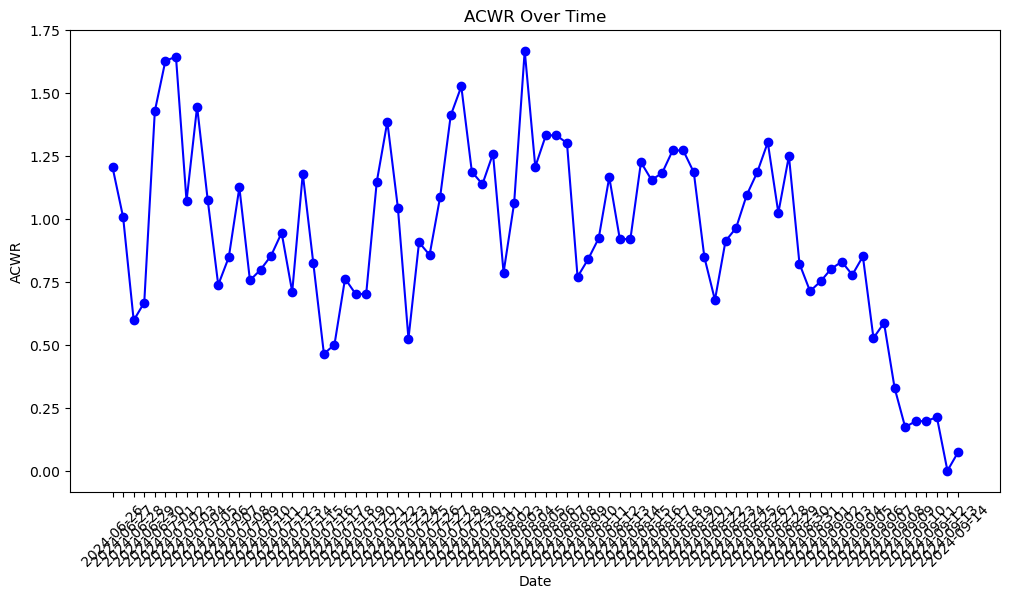

In [115]:
# plot a line chart of the ACWR over time
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(combodf['Date'], combodf['ACWR'], marker='o', linestyle='-', color='b')
plt.title('ACWR Over Time')
plt.xlabel('Date')
plt.ylabel('ACWR')
plt.xticks(rotation=45)
plt.show()